In [2]:
import pandas as pd
import numpy as np

df_output = pd.read_csv("nilai_output_imk.csv")
df_perusahaan = pd.read_csv("perusahaan_imk.csv")
df_tenaga_kerja = pd.read_csv("tenaga_kerja_imk.csv")

print("Info Data Nilai Output")
df_output.info()
df_output.head()
print("\nInfo Data Perusahaan")
df_perusahaan.info()
df_perusahaan.head()
print("\nInfo Data Tenaga Kerja")
df_tenaga_kerja.info()
df_tenaga_kerja.head()
print("\n")

Info Data Nilai Output
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429 entries, 0 to 428
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   provinsi   429 non-null    object 
 1   tahun      429 non-null    int64  
 2   mikro      395 non-null    float64
 3   kecil      395 non-null    float64
 4   pulau      418 non-null    object 
 5   latitude   418 non-null    float64
 6   longitude  418 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 23.6+ KB

Info Data Perusahaan
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   provinsi           418 non-null    object 
 1   tahun              418 non-null    int64  
 2   mikro              384 non-null    float64
 3   kecil              384 non-null    float64
 4   jumlah_perusahaan  418 non-null

In [3]:
# 1. Mengubah nama kolom mikro & kecil agar jelas sumber datanya saat digabung
df_out_clean = df_output.rename(columns={'mikro': 'nilai_output_mikro', 'kecil': 'nilai_output_kecil'})
df_per_clean = df_perusahaan.rename(columns={'mikro': 'perusahaan_mikro', 'kecil': 'perusahaan_kecil'})
df_tk_clean = df_tenaga_kerja.rename(columns={'mikro': 'tenaga_kerja_mikro', 'kecil': 'tenaga_kerja_kecil'})

# 2. Menghapus baris 'INDONESIA' agar fokus pada visualisasi spasial tingkat provinsi
df_out_clean = df_out_clean[df_out_clean['provinsi'] != 'INDONESIA']
df_per_clean = df_per_clean[df_per_clean['provinsi'] != 'INDONESIA']
df_tk_clean = df_tk_clean[df_tk_clean['provinsi'] != 'INDONESIA']

# 3. Mengambil kolom penting saja dari dataset pendukung untuk menghindari duplikasi koordinat
df_per_sub = df_per_clean[['provinsi', 'tahun', 'perusahaan_mikro', 'perusahaan_kecil', 'jumlah_perusahaan']]
df_tk_sub = df_tk_clean[['provinsi', 'tahun', 'tenaga_kerja_mikro', 'tenaga_kerja_kecil', 'jumlah_tenaga_kerja']]

# 4. Menggabungkan ketiganya berdasarkan provinsi dan tahun
df_master = pd.merge(df_out_clean, df_per_sub, on=['provinsi', 'tahun'], how='outer')
df_master = pd.merge(df_master, df_tk_sub, on=['provinsi', 'tahun'], how='outer')

# 5. Mengurutkan posisi kolom agar rapi dan terstruktur
kolom_urut = [
    'provinsi', 'tahun', 'pulau', 'latitude', 'longitude',
    'nilai_output_mikro', 'nilai_output_kecil',
    'perusahaan_mikro', 'perusahaan_kecil', 'jumlah_perusahaan',
    'tenaga_kerja_mikro', 'tenaga_kerja_kecil', 'jumlah_tenaga_kerja'
]
df_master = df_master[kolom_urut]

print("Ukuran dataset setelah digabungkan:", df_master.shape)
print("Jumlah missing values awal:")
print(df_master.isnull().sum())

Ukuran dataset setelah digabungkan: (418, 13)
Jumlah missing values awal:
provinsi                0
tahun                   0
pulau                   0
latitude                0
longitude               0
nilai_output_mikro     34
nilai_output_kecil     34
perusahaan_mikro       34
perusahaan_kecil       34
jumlah_perusahaan       0
tenaga_kerja_mikro     34
tenaga_kerja_kecil     34
jumlah_tenaga_kerja     0
dtype: int64


In [4]:
print("Baris-baris dengan missing values:\n")
display(df_master[df_master['nilai_output_mikro'].isnull()])

Baris-baris dengan missing values:



,provinsi,tahun,pulau,latitude,longitude,nilai_output_mikro,nilai_output_kecil,perusahaan_mikro,perusahaan_kecil,jumlah_perusahaan,tenaga_kerja_mikro,tenaga_kerja_kecil,jumlah_tenaga_kerja
165,KALIMANTAN UTARA,2013,Kalimantan,3.073798,116.041703,NaN,NaN,NaN,NaN,0.0,40502.0,30736.0,71238.0
166,KALIMANTAN UTARA,2014,Kalimantan,3.073798,116.041703,NaN,NaN,NaN,NaN,0.0,31717.0,14957.0,46674.0
275,PAPUA BARAT DAYA,2013,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
276,PAPUA BARAT DAYA,2014,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
277,PAPUA BARAT DAYA,2015,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
278,PAPUA BARAT DAYA,2017,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
279,PAPUA BARAT DAYA,2018,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
280,PAPUA BARAT DAYA,2019,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
281,PAPUA BARAT DAYA,2020,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
282,PAPUA BARAT DAYA,2021,Maluku & Papua,-1.800000,132.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0


In [5]:
#Mengisi nilai kosong (NaN) dengan angka 0 pada kolom numerik
kolom_numerik = df_master.columns[5:]
df_master[kolom_numerik] = df_master[kolom_numerik].fillna(0)

print("Jumlah missing values setelah penanganan:")
print(df_master.isnull().sum())

print("\nSampel data akhir:")
display(df_master.head())

df_master.to_csv("data_imk_spasiotemporal_ready.csv", index=False)

Jumlah missing values setelah penanganan:
provinsi               0
tahun                  0
pulau                  0
latitude               0
longitude              0
nilai_output_mikro     0
nilai_output_kecil     0
perusahaan_mikro       0
perusahaan_kecil       0
jumlah_perusahaan      0
tenaga_kerja_mikro     0
tenaga_kerja_kecil     0
jumlah_tenaga_kerja    0
dtype: int64

Sampel data akhir:


,provinsi,tahun,pulau,latitude,longitude,nilai_output_mikro,nilai_output_kecil,perusahaan_mikro,perusahaan_kecil,jumlah_perusahaan,tenaga_kerja_mikro,tenaga_kerja_kecil,jumlah_tenaga_kerja
0,ACEH,2013,Sumatera,4.695135,96.749397,3203779.0,2668623.0,74880.0,3688.0,78568.0,130174.0,26670.0,156844.0
1,ACEH,2014,Sumatera,4.695135,96.749397,3309411.0,1241252.0,69316.0,1715.0,71031.0,111695.0,13283.0,124978.0
2,ACEH,2015,Sumatera,4.695135,96.749397,3684835.0,751272.0,64009.0,1483.0,65492.0,112728.0,9777.0,122505.0
3,ACEH,2017,Sumatera,4.695135,96.749397,5977476.0,1477440.0,96294.0,2983.0,99277.0,161626.0,19677.0,181303.0
4,ACEH,2018,Sumatera,4.695135,96.749397,6795754.0,2012485.0,110701.0,3341.0,114042.0,179898.0,24414.0,204312.0


In [6]:
from sklearn.preprocessing import StandardScaler

fitur_numerik = [
    'nilai_output_mikro', 'nilai_output_kecil',
    'perusahaan_mikro', 'perusahaan_kecil', 'jumlah_perusahaan',
    'tenaga_kerja_mikro', 'tenaga_kerja_kecil', 'jumlah_tenaga_kerja'
]

scaler = StandardScaler()

df_scaled_features = scaler.fit_transform(df_master[fitur_numerik])

df_master_scaled = df_master.copy()
nama_kolom_scaled = [f"{col}_scaled" for col in fitur_numerik]
df_master_scaled[nama_kolom_scaled] = df_scaled_features

print("Standardisasi selesai!")
print("Kolom baru yang ternormalisasi (siap untuk K-Means):", nama_kolom_scaled)

df_master_scaled.to_csv("data_imk_spasiotemporal_final.csv", index=False)

Standardisasi selesai!
Kolom baru yang ternormalisasi (siap untuk K-Means): ['nilai_output_mikro_scaled', 'nilai_output_kecil_scaled', 'perusahaan_mikro_scaled', 'perusahaan_kecil_scaled', 'jumlah_perusahaan_scaled', 'tenaga_kerja_mikro_scaled', 'tenaga_kerja_kecil_scaled', 'jumlah_tenaga_kerja_scaled']


In [7]:
print("Perbandingan Data Sebelum dan Sesudah Normalisasi:")
df_compare = df_master[['nilai_output_mikro', 'perusahaan_mikro', 'tenaga_kerja_mikro']].head()
df_compare['nilai_output_mikro_scaled'] = df_master_scaled['nilai_output_mikro_scaled'].head()
df_compare['perusahaan_mikro_scaled'] = df_master_scaled['perusahaan_mikro_scaled'].head()
df_compare['tenaga_kerja_mikro_scaled'] = df_master_scaled['tenaga_kerja_mikro_scaled'].head()
display(df_compare)

Perbandingan Data Sebelum dan Sesudah Normalisasi:


,nilai_output_mikro,perusahaan_mikro,tenaga_kerja_mikro,nilai_output_mikro_scaled,perusahaan_mikro_scaled,tenaga_kerja_mikro_scaled
0,3203779.0,74880.0,130174.0,-0.340682,-0.140106,-0.158048
1,3309411.0,69316.0,111695.0,-0.334295,-0.170553,-0.212286
2,3684835.0,64009.0,112728.0,-0.311593,-0.199594,-0.209254
3,5977476.0,96294.0,161626.0,-0.172956,-0.022924,-0.065733
4,6795754.0,110701.0,179898.0,-0.123474,0.055914,-0.012103


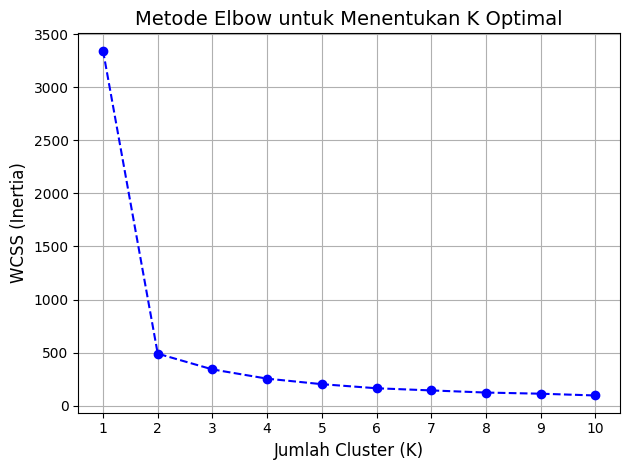

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

fitur_numerik = [
    'nilai_output_mikro', 'nilai_output_kecil',
    'perusahaan_mikro', 'perusahaan_kecil', 'jumlah_perusahaan',
    'tenaga_kerja_mikro', 'tenaga_kerja_kecil', 'jumlah_tenaga_kerja'
]

fitur_scaled = df_master_scaled[[f"{col}_scaled" for col in fitur_numerik]]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(fitur_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan K Optimal', fontsize=14)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.grid(True)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=300)
plt.show()

In [9]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_master['cluster_raw'] = kmeans_final.fit_predict(fitur_scaled)

# Membuat urutan otomatis dari yang produktivitasnya terendah ke tertinggi
urutan_cluster = df_master.groupby('cluster_raw')['jumlah_perusahaan'].mean().sort_values().index.tolist()
kamus_pemetaan = {id_lama: id_baru for id_baru, id_lama in enumerate(urutan_cluster)}

df_master['cluster'] = df_master['cluster_raw'].map(kamus_pemetaan)

print("DISTRIBUSI KLASTER")
print(df_master['cluster'].value_counts().sort_index())
print("\nTotal data keseluruhan:", df_master['cluster'].value_counts().sum())

DISTRIBUSI KLASTER
cluster
0    243
1    142
2     21
3     12
Name: count, dtype: int64

Total data keseluruhan: 418


Silhouette Score Global (K=4): 0.5669

Rata-rata Silhouette Score per Cluster:
  Cluster 0: 0.7417
  Cluster 1: 0.2773
  Cluster 2: 0.3064
  Cluster 3: 0.4712

Interpretasi: Cukup baik — cluster memiliki struktur yang reasonable



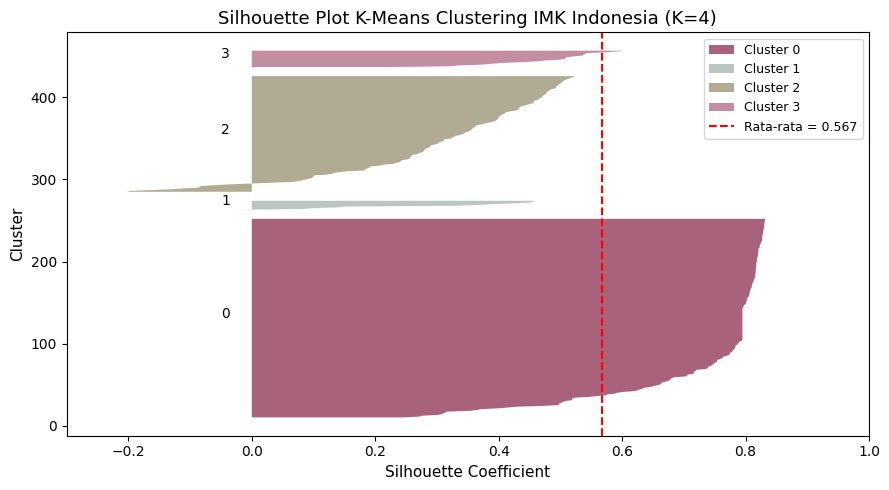

Silhouette plot tersimpan sebagai silhouette_plot.png


In [10]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fitur_eval = df_master_scaled[[f"{col}_scaled" for col in fitur_numerik]]
label_cluster = df_master["cluster_raw"]

sil_score = silhouette_score(fitur_eval, label_cluster)
print(f"Silhouette Score Global (K=4): {sil_score:.4f}")
print()

sil_values = silhouette_samples(fitur_eval, label_cluster)
print("Rata-rata Silhouette Score per Cluster:")
for k in sorted(label_cluster.unique()):
    skor_k = sil_values[label_cluster == k].mean()
    print(f"  Cluster {k}: {skor_k:.4f}")
print()

if sil_score >= 0.7:
    interpretasi = "Sangat baik — struktur cluster kuat dan terpisah jelas"
elif sil_score >= 0.5:
    interpretasi = "Cukup baik — cluster memiliki struktur yang reasonable"
elif sil_score >= 0.25:
    interpretasi = "Lemah — cluster terbentuk tapi batas antar cluster tidak tegas"
else:
    interpretasi = "Buruk — kemungkinan K tidak optimal atau data overlap"
print(f"Interpretasi: {interpretasi}")
print()

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
n_clusters = 4
colors = ["#933B5B", "#AABAAE", "#9F9679", "#B5728A"]

for k in range(n_clusters):
    sil_k = np.sort(sil_values[label_cluster == k])
    size_k = sil_k.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     facecolor=colors[k], alpha=0.8, label=f"Cluster {k}")
    ax.text(-0.05, y_lower + 0.5 * size_k, str(k), fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=sil_score, color="red", linestyle="--", linewidth=1.5,
           label=f"Rata-rata = {sil_score:.3f}")
ax.set_title("Silhouette Plot K-Means Clustering IMK Indonesia (K=4)", fontsize=13)
ax.set_xlabel("Silhouette Coefficient", fontsize=11)
ax.set_ylabel("Cluster", fontsize=11)
ax.legend(loc="upper right", fontsize=9)
ax.set_xlim([-0.3, 1.0])
plt.tight_layout()
plt.savefig("silhouette_plot.png", dpi=300, bbox_inches="tight")
plt.show()
print("Silhouette plot tersimpan sebagai silhouette_plot.png")

In [11]:
import plotly.express as px

df_master = df_master.sort_values(by='tahun')

df_master['kategori_cluster'] = df_master['cluster'].map({
    0: 'Cluster 0: Super Masif (Kecil Dominan)',
    1: 'Cluster 1: Rendah / Berkembang',
    2: 'Cluster 2: Sedang / Potensial',
    3: 'Cluster 3: Sangat Tinggi (Mikro Dominan)'
})


fig = px.scatter(
    df_master,
    x="jumlah_perusahaan",
    y="nilai_output_mikro",
    color="cluster",
    hover_name="provinsi",
    log_x=True,
    log_y=True,
    title="Sebaran Cluster IMK Indonesia (Tampilan 4 Cluster Terpisah)"
)

fig.show()

In [12]:
import plotly.express as px
import pandas as pd

df_master = df_master.sort_values(by='tahun')

df_master['Kategori_Cluster'] = df_master['cluster'].map({
    0: 'Cluster 0: Raksasa IMK (Kecil Dominan)',
    1: 'Cluster 1: Produktivitas IMK Rendah',
    2: 'Cluster 2: Produktivitas IMK Sedang',
    3: 'Cluster 3: Raksasa IMK (Mikro Dominan)'
})

kategori_tetap = [
    'Cluster 0: Raksasa IMK (Kecil Dominan)',
    'Cluster 1: Produktivitas IMK Rendah',
    'Cluster 2: Produktivitas IMK Sedang',
    'Cluster 3: Raksasa IMK (Mikro Dominan)'
]
df_master['Kategori_Cluster'] = pd.Categorical(df_master['Kategori_Cluster'], categories=kategori_tetap, ordered=True)

fig = px.scatter_mapbox(
    df_master,
    lat="latitude",
    lon="longitude",
    color="Kategori_Cluster",
    size="jumlah_perusahaan",
    hover_name="provinsi",
    hover_data={
        "tahun": True,
        "nilai_output_mikro": ":,.0f",
        "jumlah_tenaga_kerja": ":,.0f",
        "Kategori_Cluster": False
    },
    animation_frame="tahun",
    title="Peta Sebaran Spasio-Temporal Hasil Klastering IMK Indonesia (2013-2024)",
    mapbox_style="open-street-map",
    zoom=3.8,
    center={"lat": -2.5, "lon": 118},
    width=1150,
    height=680,
    category_orders={"Kategori_Cluster": kategori_tetap}
)

fig.update_layout(
    legend_title_text='Kelompok Hasil Analisis K-Means',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

In [13]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df_list_final = []

for thn in df_master['tahun'].unique():
    df_thn = df_master[df_master['tahun'] == thn].copy()

    df_thn['nilai_output'] = df_thn['nilai_output_mikro'] + df_thn['nilai_output_kecil']

    fitur = df_thn[['jumlah_perusahaan', 'jumlah_tenaga_kerja', 'nilai_output']]

    scaler = StandardScaler()
    fitur_scaled = scaler.fit_transform(fitur)

    kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
    df_thn['cluster_id'] = kmeans.fit_predict(fitur_scaled)

    df_list_final.append(df_thn)

df_master_berklaster = pd.concat(df_list_final, ignore_index=True)

df_master_berklaster.to_csv("data_imk.csv", index=False)
print("Selesai! File 'data_imk.csv' dengan K=4 berhasil dibuat!")

Selesai! File 'data_imk.csv' dengan K=4 berhasil dibuat!


In [14]:
import pandas as pd

df = pd.read_csv("data_imk.csv")
print(df.columns.tolist())
print(df.head())

['provinsi', 'tahun', 'pulau', 'latitude', 'longitude', 'nilai_output_mikro', 'nilai_output_kecil', 'perusahaan_mikro', 'perusahaan_kecil', 'jumlah_perusahaan', 'tenaga_kerja_mikro', 'tenaga_kerja_kecil', 'jumlah_tenaga_kerja', 'cluster_raw', 'cluster', 'kategori_cluster', 'Kategori_Cluster', 'nilai_output', 'cluster_id']
         provinsi  tahun     pulau  latitude   longitude  nilai_output_mikro  \
0       KEP. RIAU   2013  Sumatera  3.945398  108.142571            796936.0   
1         LAMPUNG   2013  Sumatera -4.557573  105.406811           6116332.0   
2        BENGKULU   2013  Sumatera -3.793130  102.265808            848139.0   
3          BANTEN   2013      Jawa -6.405876  106.102921           2612996.0   
4  SUMATERA UTARA   2013  Sumatera  2.115830   99.538753           5116140.0   

   nilai_output_kecil  perusahaan_mikro  perusahaan_kecil  jumlah_perusahaan  \
0            821543.0           13706.0            2515.0            16221.0   
1           5134935.0           900